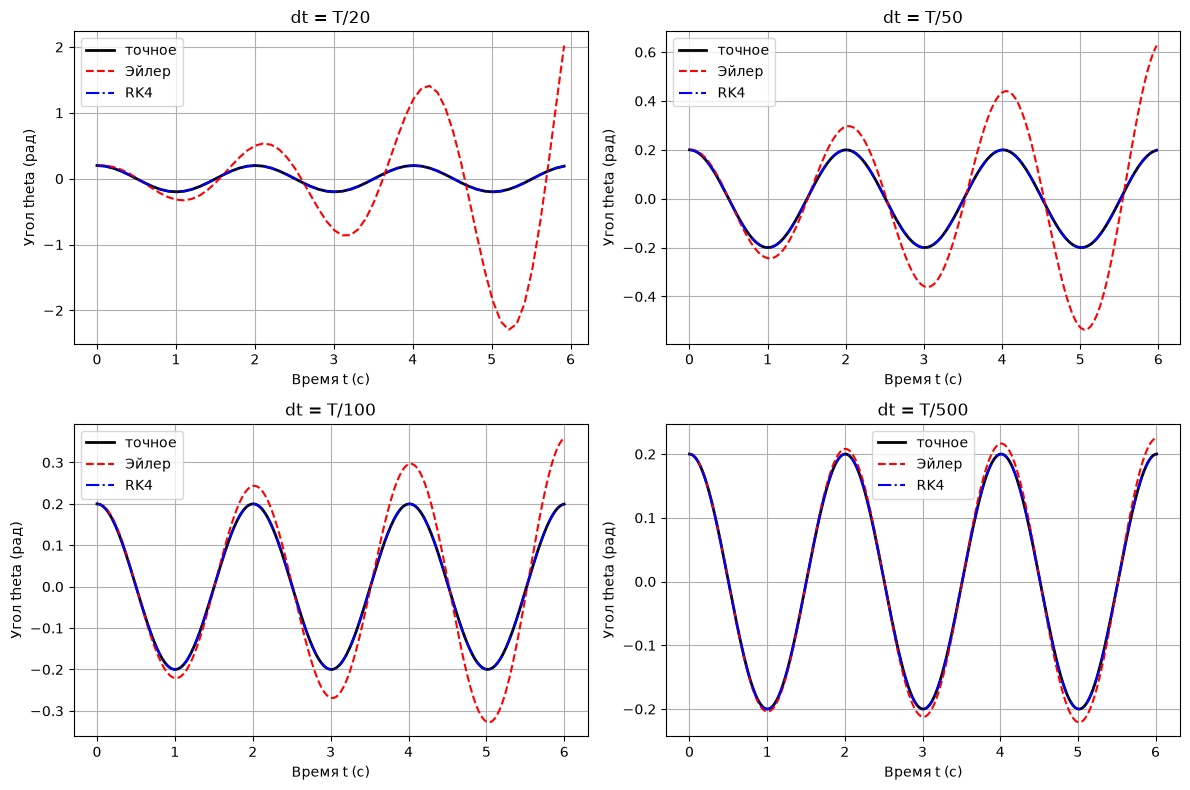

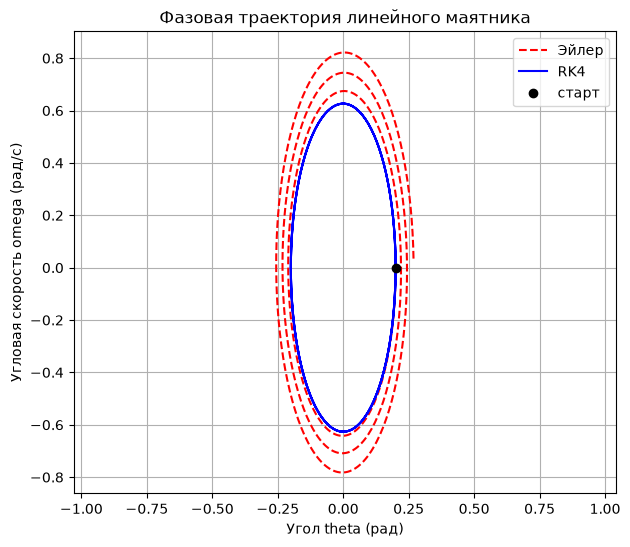

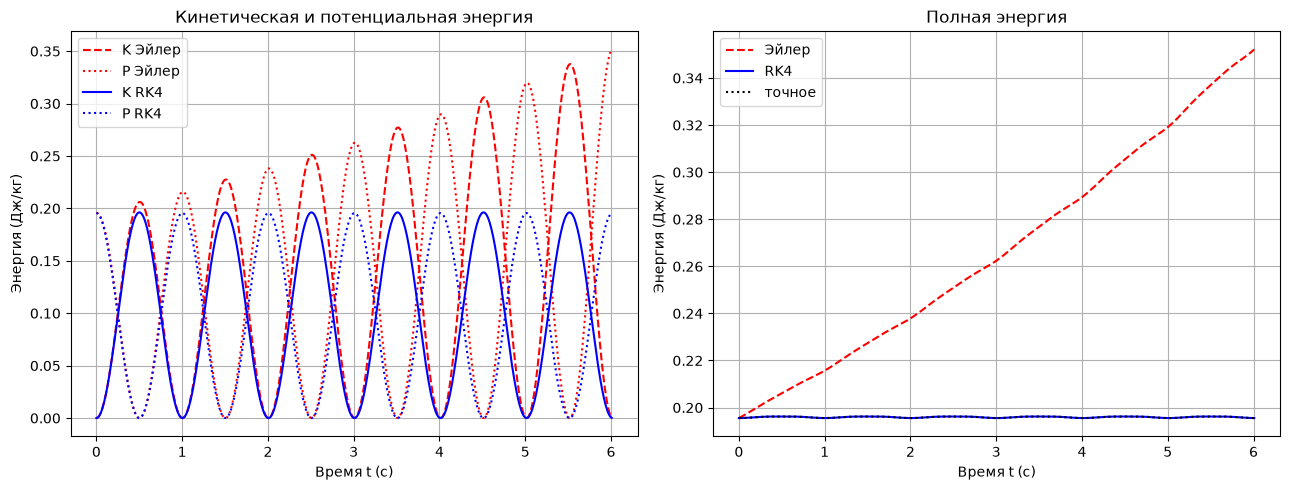

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Параметры задачи
g = 9.81                          # ускорение свободного падения (м/с^2)
L = 1.0                           # длина маятника (м)
m = 1.0                           # масса маятника (кг)

omega = np.sqrt(g / L)            # собственная частота
T = 2 * np.pi / omega             # период колебаний

theta0 = 0.2                      # начальный угол (рад)
dtheta0 = 0.0                     # начальная угловая скорость (рад/с)

t_start = 0.0
t_end = 3 * T


# Точное решение линейного маятника

def exact_linear(t):
    return theta0 * np.cos(omega * t) + (dtheta0 / omega) * np.sin(omega * t)


# Правая часть системы уравнений линейного маятника

def pendulum_derivatives_linear(theta, omega_angle):
    """
    theta       - угол (рад)
    omega_angle - угловая скорость (рад/с)
    """
    dtheta_dt = omega_angle                    # производная угла
    domega_dt = -(omega ** 2) * theta          # производная угловой скорости
    return dtheta_dt, domega_dt

# Метод Эйлера

def solve_pendulum_euler(theta0, omega0, time):
    """
    theta0 - начальный угол (рад)
    omega0 - начальная угловая скорость (рад/с)
    time   - массив времени
    """
    N = len(time)
    dt = time[1] - time[0]

    theta = np.zeros(N)
    omega_ang = np.zeros(N)

    theta[0] = theta0
    omega_ang[0] = omega0

    for i in range(N - 1):
        th = theta[i]
        w = omega_ang[i]

        dth, dw = pendulum_derivatives_linear(th, w)

        theta[i + 1] = th + dt * dth
        omega_ang[i + 1] = w + dt * dw

    return theta, omega_ang


# Метод Рунге-Кутты 4-го порядка

def solve_pendulum_RK4(theta0, omega0, time):
    """
    theta0 - начальный угол (рад)
    omega0 - начальная угловая скорость (рад/с)
    time   - массив времени
    """
    N = len(time)
    dt = time[1] - time[0]

    theta = np.zeros(N)
    omega_ang = np.zeros(N)

    theta[0] = theta0
    omega_ang[0] = omega0

    for i in range(N - 1):
        th = theta[i]
        w = omega_ang[i]

        # k1
        k1_th, k1_w = pendulum_derivatives_linear(th, w)

        # k2
        k2_th, k2_w = pendulum_derivatives_linear(
            th + 0.5 * dt * k1_th,
            w + 0.5 * dt * k1_w
        )

        # k3
        k3_th, k3_w = pendulum_derivatives_linear(
            th + 0.5 * dt * k2_th,
            w + 0.5 * dt * k2_w
        )

        # k4
        k4_th, k4_w = pendulum_derivatives_linear(
            th + dt * k3_th,
            w + dt * k3_w
        )

        theta[i + 1] = th + (dt / 6.0) * (k1_th + 2 * k2_th + 2 * k3_th + k4_th)
        omega_ang[i + 1] = w + (dt / 6.0) * (k1_w + 2 * k2_w + 2 * k3_w + k4_w)

    return theta, omega_ang


# Кинетическая и потенциальная энергия (на единицу массы)

def energies(theta, omega_angle):
    """
    theta       - массив углов (рад)
    omega_angle - массив угловых скоростей (рад/с)
    """
    E_kin = 0.5 * (L * omega_angle) ** 2
    E_pot = g * L * (1 - np.cos(theta))
    return E_kin, E_pot


# Сравнение с точным решением для нескольких шагов

def plot_comparison():
    steps = [T / 20, T / 50, T / 100, T / 500]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for ax, dt in zip(axes.flat, steps):
        time = np.arange(t_start, t_end, dt)

        theta_e, _ = solve_pendulum_euler(theta0, dtheta0, time)
        theta_r, _ = solve_pendulum_RK4(theta0, dtheta0, time)

        ax.plot(time, exact_linear(time), 'k-', lw=2, label='точное')
        ax.plot(time, theta_e, 'r--', label='Эйлер')
        ax.plot(time, theta_r, 'b-.', label='RK4')

        ax.set_title(f'dt = T/{int(round(T / dt))}')
        ax.set_xlabel('Время t (с)')
        ax.set_ylabel('Угол theta (рад)')
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()


# Фазовая траектория

def plot_phase():
    dt = T / 200
    time = np.arange(t_start, t_end, dt)

    theta_e, omega_e = solve_pendulum_euler(theta0, dtheta0, time)
    theta_r, omega_r = solve_pendulum_RK4(theta0, dtheta0, time)

    plt.figure(figsize=(7, 6))
    plt.plot(theta_e, omega_e, 'r--', label='Эйлер')
    plt.plot(theta_r, omega_r, 'b-', label='RK4')
    plt.plot(theta0, dtheta0, 'ko', label='старт')

    plt.xlabel('Угол theta (рад)')
    plt.ylabel('Угловая скорость omega (рад/с)')
    plt.title('Фазовая траектория линейного маятника')
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    plt.show()


# Графики энергии

def plot_energies():
    dt = T / 200
    time = np.arange(t_start, t_end, dt)

    theta_e, omega_e = solve_pendulum_euler(theta0, dtheta0, time)
    theta_r, omega_r = solve_pendulum_RK4(theta0, dtheta0, time)

    E_k_e, E_p_e = energies(theta_e, omega_e)
    E_k_r, E_p_r = energies(theta_r, omega_r)

    theta_ex = exact_linear(time)
    omega_ex = -omega * theta0 * np.sin(omega * time)
    E_k_ex, E_p_ex = energies(theta_ex, omega_ex)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(time, E_k_e, 'r--', label='K Эйлер')
    axes[0].plot(time, E_p_e, 'r:',  label='P Эйлер')
    axes[0].plot(time, E_k_r, 'b-',  label='K RK4')
    axes[0].plot(time, E_p_r, 'b:',  label='P RK4')
    axes[0].set_title('Кинетическая и потенциальная энергия')
    axes[0].set_xlabel('Время t (с)')
    axes[0].set_ylabel('Энергия (Дж/кг)')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(time, E_k_e + E_p_e, 'r--', label='Эйлер')
    axes[1].plot(time, E_k_r + E_p_r, 'b-',  label='RK4')
    axes[1].plot(time, E_k_ex + E_p_ex, 'k:', label='точное')
    axes[1].set_title('Полная энергия')
    axes[1].set_xlabel('Время t (с)')
    axes[1].set_ylabel('Энергия (Дж/кг)')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()



if __name__ == "__main__":
    plot_comparison()
    plot_phase()
    plot_energies()